In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import trim_mean
import math
from pandas.api.types import ( is_numeric_dtype, is_categorical_dtype, is_object_dtype, is_datetime64_any_dtype )
from default_risk.scripts.variable_profiling import eda_per_table_printing_results
from default_risk.scripts.variable_profiling import eda_per_table_persisting_result_html
from default_risk.scripts.variable_profiling import create_files_nulls_per_colmun
import default_risk.config as cfg
from default_risk.scripts.auxiliar_eda_function import check_invariant
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import dtale
import logging

log = logging.getLogger('werkzeug')

bureau_df= pd.read_csv(cfg.BUREAU)

data_frame_size=len(bureau_df)

with open(cfg.SCHEMA_JSON, "r") as f:
    schema = json.load(f)

Invariants found at the moment: (# number of cell with the proofs and relevant code)

1- The factical enndate always point to the past: DAYS_CREDIT_ENDDATE < 0 (100%) #5


Soft constraints:

1- if have a factical end date defined ("DAYS_ENDDATE_FACT" != null), the loan is not active ("CREDICT_ACTIVE" != "Active") (99.9%) #3
Anomalies: Potential data corruption. 

2- if the contract are marked as closed ("CREDICT_ACTIVE" == "Closed") then the conctract have defined a factical end date ("DAYS_ENDDATE_FACT" != null) (99.99%)

Decisions summary: 

1- In cases where the soft constraint #1 is violated, we will input the status as "Closed" taking the DAYS_ENDDATE_FACT as source of true.

2- In cases where the soft contraint #2 we will drop the observations asumming data corruption.

In [3]:
#1
#create the files por data data dictionary
create_files_nulls_per_colmun(bureau_df,"bureu")

In [4]:
#2
#run the screening script on bureau
eda_per_table_printing_results(bureau_df, schema, "bureau",False)

--------------------------------------
SK_ID_CURR
basic_data


,cardinality,mode
0,305811,[120860]


frequency


,CATEGORY,COUNT,SEGMENT
0,120860,116,top
1,169704,94,top
2,318065,78,top
3,251643,61,top
4,425396,60,top
5,295809,59,top
6,129843,58,top
7,385133,57,top
8,177014,56,top
9,280155,55,top


--------------------------------------
SK_ID_BUREAU
basic_data


...

,min,max,mean,trim_mean,median,standard_deviation,standard_error,coefficient_of_variation
0,0.0,118453423.5,15712.7577,5918.080778,0.0,325826.949053,465.639579,20.736459


missings_metrics


,nulls_amount,nulls_porcentaje,non_null_amount,non_null_porcentaje
0,1226791,71.47349,489637,28.52651


distribution_metrics


,skew,p90,p99,ratio_p99_p90,ratio_max_value_p99
0,212.543125,31432.5,118451.88,3.768452,1000.013031


In [5]:
#3
check_invariant((bureau_df["DAYS_ENDDATE_FACT"] > 0),"the factical enndate is positive (future date)",data_frame_size)

active_mask= (bureau_df["CREDIT_ACTIVE"] == "Active")
have_endate_mask= (bureau_df["DAYS_ENDDATE_FACT"].notna())
check_invariant((active_mask & have_endate_mask),"we have defined a factical date of end of contract but it's flagged as active",data_frame_size)

is_closed_mask= (bureau_df["CREDIT_ACTIVE"] == "Closed")
check_invariant((is_closed_mask & (~have_endate_mask)),"where are closed without factical endate",data_frame_size)

0 of cases where the factical enndate is positive (future date)
that represent a 0.0% of cases with violation of this invariant 

1969 of cases where we have defined a factical date of end of contract but it's flagged as active
that represent a 0.1147149778493476% of cases with violation of this invariant 

125 of cases where where are closed without factical endate
that represent a 0.0072825658868300915% of cases with violation of this invariant 



In [6]:
#4
#in order to understand the nulls in "AMT_ANNUITY"
bureau_prev_contract_without_annuity= bureau_df[bureau_df["AMT_ANNUITY"].isnull()]
len(bureau_prev_contract_without_annuity)
rows_to_analyze=bureau_prev_contract_without_annuity[bureau_prev_contract_without_annuity["CREDIT_ACTIVE"] == "Active"]
print(rows_to_analyze["CREDIT_TYPE"].value_counts())
#seems like active loans of all kind can have AMT_ANNUITY as missing value. 
#This suggest that missing values are more correlated with the way the data are gathering than with the nature of the loans in the sample.

CREDIT_TYPE
Consumer credit                                 208321
Credit card                                     206898
Mortgage                                          8047
Car loan                                          6267
Microloan                                         1406
Loan for business development                      230
Another type of loan                               156
Loan for working capital replenishment             118
Unknown type of loan                                83
Real estate loan                                    11
Cash loan (non-earmarked)                            8
Loan for the purchase of equipment                   2
Loan for purchase of shares (margin lending)         2
Name: count, dtype: int64


In [7]:
#5
#in order to understand the missing values in "DAYS_ENDDATE_FACT"
without_endate= bureau_df[bureau_df["DAYS_ENDDATE_FACT"].isnull()]
len(without_endate)
print("status of observations with enndate in null:")
print(without_endate["CREDIT_ACTIVE"].value_counts())
print("status of all the dataset:")
print(bureau_df["CREDIT_ACTIVE"].value_counts())
#we have 125 rows without endate_fact but marked as closed. 



status of observations with enndate in null:
CREDIT_ACTIVE
Active      628638
Sold          4879
Closed         125
Bad debt        11
Name: count, dtype: int64
status of all the dataset:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64


In [8]:
have_no_limit_card_mask= (bureau_df["AMT_CREDIT_SUM_LIMIT"].isnull()) 
credit_card_loan_mask= (bureau_df["CREDIT_TYPE"] == "Credit card")
is_active_mask= (bureau_df["CREDIT_ACTIVE"] == "Active")
rows_to_analyze= bureau_df[have_no_limit_card_mask & credit_card_loan_mask & is_active_mask]


print("we have " + str((credit_card_loan_mask & is_active_mask).sum()) + " active credit card loans")
print("where " + str(len(rows_to_analyze)) + " have no limit defined")

dtale.show(rows_to_analyze)
#this observation don't let clear the reason to exist credit card loans without limit but was useful to realize there is loans like 
#SK_ID_BUREAU = 5714465 where AMT_CREDIT_SUM is 0 and AMT_CREDIT_SUM_DEBT == 0 or nan at the same time. And with those 2 fields without providing info we don't have how to figured out the ammount of 
#the debt. This expose the need of define a minimun ammount of info provided for a observation to be considered in this table due the poor quality of the data.

we have 285998 active credit card loans
where 66256 have no limit defined


2026-05-12 19:23:03,237 - ERROR    - Exception on /health [GET]
Traceback (most recent call last):
  File "c:\Users\kuroc\OneDrive\Escritorio\default risk\default-risk\Lib\site-packages\flask\app.py", line 2529, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kuroc\OneDrive\Escritorio\default risk\default-risk\Lib\site-packages\flask\app.py", line 1825, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kuroc\OneDrive\Escritorio\default risk\default-risk\Lib\site-packages\flask\app.py", line 1821, in full_dispatch_request
    rv = self.preprocess_request()
         ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kuroc\OneDrive\Escritorio\default risk\default-risk\Lib\site-packages\flask\app.py", line 2313, in preprocess_request
    rv = self.ensure_sync(before_func)()
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kuroc\OneDrive\Escritorio\defa

11373
39576


<Axes: xlabel='DAYS_CREDIT_UPDATE', ylabel='Count'>

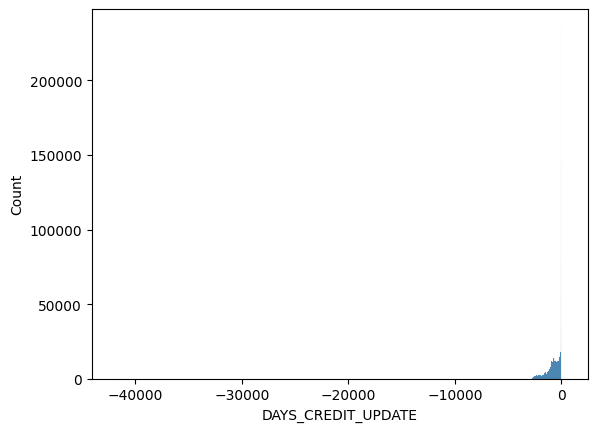

In [9]:


col = bureau_df["AMT_CREDIT_SUM_LIMIT"]
#checking if there is very high values different that the max value (possible sentinel)
mask = (col > 30000) & (col != 31199.0)
mask2 = (col > 10950)
#checking if the ammout of values that will get clipped if i cap the column in 30 years
no_that_long = mask2.sum() - mask.sum()
print(no_that_long)
print(mask.sum())
sns.histplot(data= bureau_df, x="DAYS_CREDIT_UPDATE")

<Axes: xlabel='DAYS_CREDIT_UPDATE', ylabel='Density'>

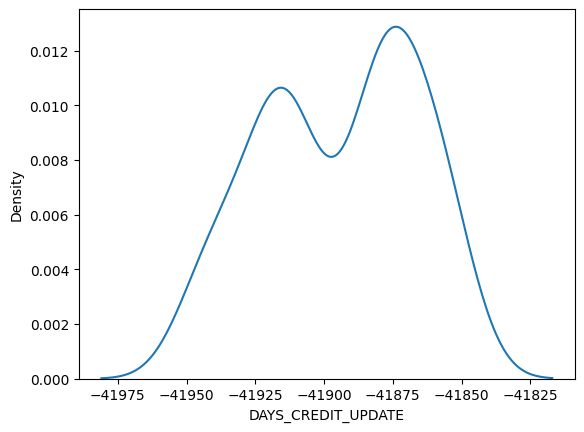

In [10]:
subset = bureau_df[bureau_df["DAYS_CREDIT_UPDATE"] < -10950]
sns.kdeplot(data=subset, x="DAYS_CREDIT_UPDATE")


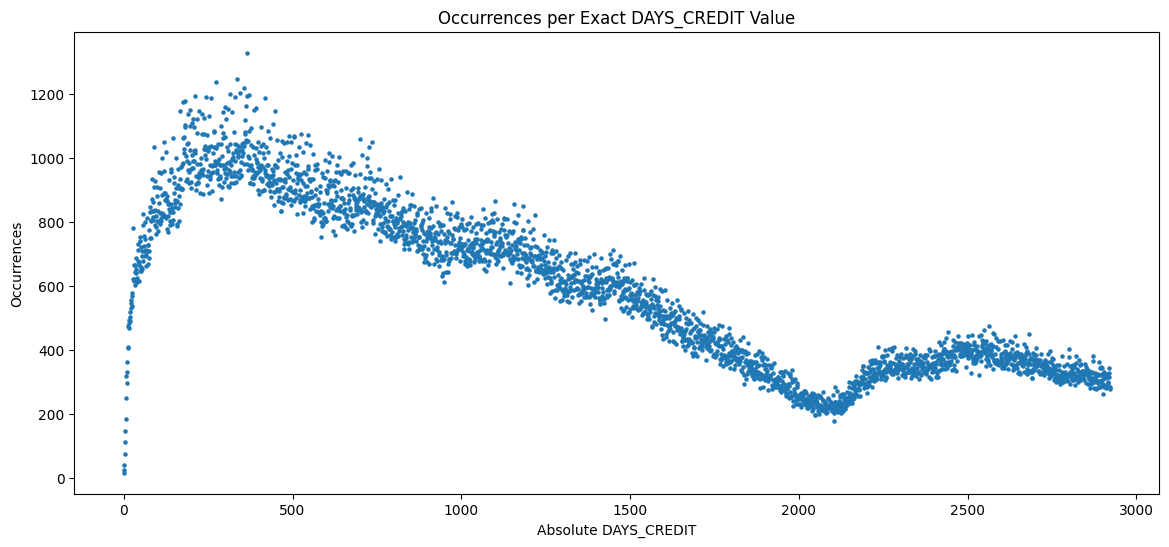

In [11]:

column_to_analize= bureau_df["DAYS_CREDIT"]

counts = (
    column_to_analize
    .abs()
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(14, 6))

plt.scatter(
    counts.index,
    counts.values,
    s=5
)

plt.title("Occurrences per Exact DAYS_CREDIT Value")

plt.xlabel("Absolute DAYS_CREDIT")
plt.ylabel("Occurrences")

plt.show()

3492


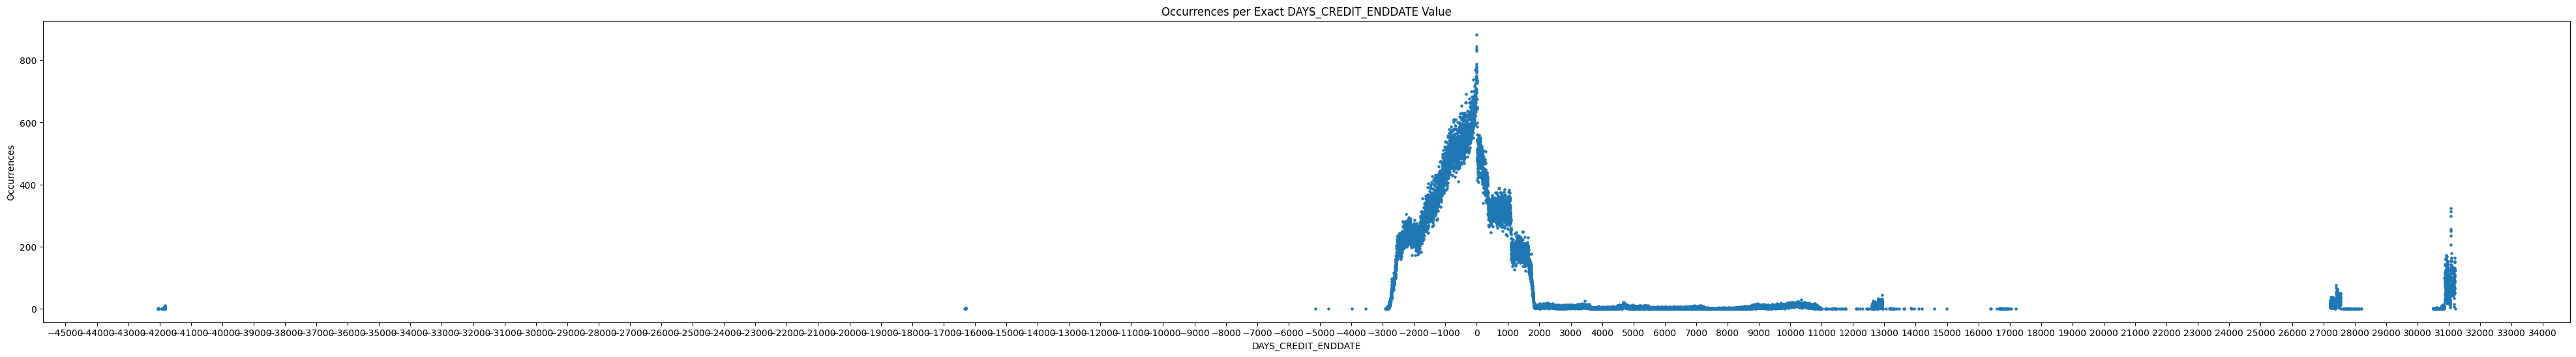

In [61]:
column_to_analize= bureau_df["DAYS_CREDIT_ENDDATE"]

counts = (
    column_to_analize
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(50,6))

ax.scatter(
    counts.index,
    counts.values,
    s=5
)



ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.set_title("Occurrences per Exact DAYS_CREDIT_ENDDATE Value")
ax.set_xlabel("DAYS_CREDIT_ENDDATE")
ax.set_ylabel("Occurrences")

print((column_to_analize < -2700).sum())

plt.show()